## Comparison Before and After Feature Selection with Naive Bayes


## **Dataset :** Fake News Dataset  


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy.sparse import hstack
from sklearn.utils import shuffle
warnings.filterwarnings('ignore')


# date cleaner
from dateutil import parser
import datetime

# Text preprocessing
import re
import string
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, SnowballStemmer
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

# Feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

# Feature selection
from sklearn.feature_selection import SelectKBest, f_classif, chi2
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from scipy.stats import f_oneway

# Classifier
from sklearn.naive_bayes import MultinomialNB, GaussianNB, ComplementNB

# Evaluation
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, normalize

print('Toutes les bibliothèques importées avec succès!')

Toutes les bibliothèques importées avec succès!


In [2]:
try:
    df1_fake = pd.read_csv('/kaggle/input/datasets/salmahafid/fake-csv/Fake.csv')
    df1_true = pd.read_csv('/kaggle/input/datasets/salmahafid/true-csv/True.csv')

    df1_fake['label'] = 0
    df1_true['label'] = 1

    df1 = pd.concat([df1_fake, df1_true], axis=0).reset_index(drop=True)

    df1 = shuffle(df1, random_state=42).reset_index(drop=True)

    print("Data successfully merged and shuffled. !")
    print(f"Taille totale du dataset : {df1.shape[0]} lignes")

except FileNotFoundError as e:
    print(f"Erreur : {e}")
    print("Make sure that Fake.csv and True.csv are located in the same directory..")

df1.head()

Data successfully merged and shuffled. !
Taille totale du dataset : 44898 lignes


,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


In [3]:
def preprocess_date_feature(df, column_name='date'):
    
    def parse_robust(x):
        try:
            return parser.parse(str(x), fuzzy=True)
        except (ValueError, OverflowError, TypeError):
            return None

    df[column_name] = df[column_name].apply(parse_robust)


    df[column_name] = df[column_name].dt.strftime('%Y-%m-%d')
    
    return df


In [4]:
def preprocess_english(text):
    if not isinstance(text, str):
        return ''

    text = text.lower()

    text = re.sub(r'http\S+|www\S+', '', text)

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    text = re.sub(r'\s+', ' ', text).strip()

    stop_words = set(stopwords.words('english'))
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]

    stemmer = PorterStemmer()
    tokens = [stemmer.stem(t) for t in tokens]
    return ' '.join(tokens)


In [5]:
print('Dataset preprocessing in progress...')
df1 = df1.dropna().reset_index(drop=True)
df1['text'] = df1['text'].apply(preprocess_english)
df1['title'] = df1['title'].apply(preprocess_english)
df1['subject'] = df1['subject'].apply(preprocess_english)
df1 = preprocess_date_feature(df1, 'date')



print(f'\nPreprocessing completed!')


Dataset preprocessing in progress...

Preprocessing completed!


In [6]:
df1 = df1.dropna().reset_index(drop=True)

print(f"Number of rows after removing NaN values : {len(df1)}")

Number of rows after removing NaN values : 44888


=== General Information ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44888 entries, 0 to 44887
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44888 non-null  object
 1   text     44888 non-null  object
 2   subject  44888 non-null  object
 3   date     44888 non-null  object
 4   label    44888 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.7+ MB
None

=== Missing Values ===
title      0
text       0
subject    0
date       0
label      0
dtype: int64

=== Class Distribution ===
label
0    23471
1    21417
Name: count, dtype: int64


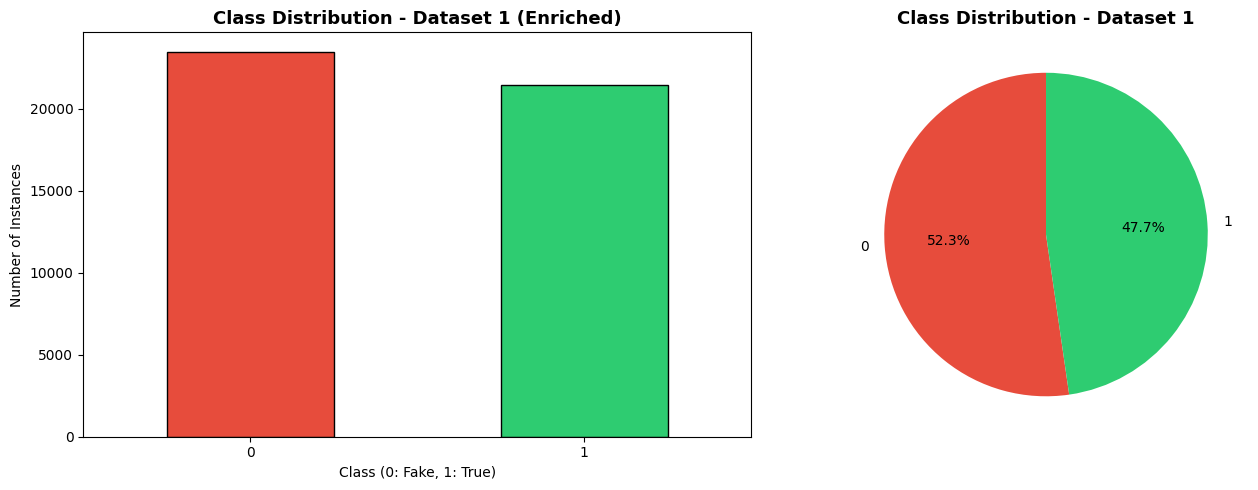

In [7]:
print('=== General Information ===')
print(df1.info())
print('\n=== Missing Values ===')
print(df1.isnull().sum())
print('\n=== Class Distribution ===')
print(df1["label"].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df1["label"].value_counts().plot(kind='bar', ax=axes[0], color=['#e74c3c','#2ecc71'], edgecolor='black')
axes[0].set_title('Class Distribution - Dataset 1 (Enriched)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Class (0: Fake, 1: True)')
axes[0].set_ylabel('Number of Instances')
axes[0].tick_params(axis='x', rotation=0)

df1["label"].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                                         colors=['#e74c3c','#2ecc71'], startangle=90)
axes[1].set_title('Class Distribution - Dataset 1', fontsize=13, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('ds1_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


In [8]:
import numpy as np
X1 = df1[['title', 'text', 'subject', 'date']]
y1 = df1['label']

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42, stratify=y1
)


tfidf_title = TfidfVectorizer(max_features=2000)
tfidf_text = TfidfVectorizer(max_features=5000)
tfidf_subject = TfidfVectorizer()
tfidf_date = TfidfVectorizer()

print("Vectorization in progress ...")


X1_train_title = tfidf_title.fit_transform(X1_train['title'])
X1_test_title = tfidf_title.transform(X1_test['title'])

X1_train_text = tfidf_text.fit_transform(X1_train['text'])
X1_test_text = tfidf_text.transform(X1_test['text'])

X1_train_subject = tfidf_subject.fit_transform(X1_train['subject'])
X1_test_subject = tfidf_subject.transform(X1_test['subject'])

X1_train_date = tfidf_date.fit_transform(X1_train['date'])
X1_test_date = tfidf_date.transform(X1_test['date'])

X1_train = hstack([X1_train_title, X1_train_text, X1_train_subject, X1_train_date])

X1_test = hstack([X1_test_title, X1_test_text, X1_test_subject, X1_test_date])

print(f"Matrices ready!")
print(f"Shape Train : {X1_train.shape}")
print(f"Shape Test  : {X1_test.shape}")


Vectorization in progress ...
Matrices ready!
Shape Train : (35910, 7043)
Shape Test  : (8978, 7043)


In [9]:

def evaluate_nb(X_train, X_test, y_train, y_test, method_name, dataset_name):

    clf = ComplementNB()
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(clf, X_train, y_train, cv=cv, scoring='accuracy')

    return {
        'Dataset': dataset_name,
        'Method': method_name,
        'Nb Features': X_train.shape[1],
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4),
        'CV Mean': round(cv_scores.mean(), 4),
        'CV Std': round(cv_scores.std(), 4),
        'y_pred': y_pred,
        'y_test': y_test
    }


In [10]:
results_ds1 = []
K_BEST = 5000

print('Without feature selection...')

res = evaluate_nb(X1_train, X1_test, y1_train, y1_test, 'Without feature selection', 'Dataset 1')
results_ds1.append(res)
print(f'   Accuracy: {res["Accuracy"]:.4f} | F1: {res["F1-Score"]:.4f}')


Without feature selection...
   Accuracy: 0.9989 | F1: 0.9989


In [11]:
print('Fisher score (chi2)...')
selector_fisher = SelectKBest(chi2, k=K_BEST)
X1_train_fisher = selector_fisher.fit_transform(X1_train, y1_train)
X1_test_fisher  = selector_fisher.transform(X1_test)


res = evaluate_nb(X1_train_fisher, X1_test_fisher, y1_train, y1_test,
                  f'Fisher (chi2, k={K_BEST})', 'Dataset 1')
print(f'   Accuracy: {res["Accuracy"]:.4f} | F1: {res["F1-Score"]:.4f}')


Fisher score (chi2)...
   Accuracy: 0.9989 | F1: 0.9989


In [12]:
print('Score de Fisher (chi2)')

selector_fisher_all = SelectKBest(chi2, k='all')
selector_fisher_all.fit(X1_train, y1_train)
scores = selector_fisher_all.scores_

seuil_max = np.percentile(scores, 99.8) 
seuil_min = 10

masque_final = (scores < seuil_max) & (scores > seuil_min)
X1_train_fisher = X1_train[:, masque_final]
X1_test_fisher  = X1_test[:, masque_final]
nb_features = masque_final.sum()


res = evaluate_nb(X1_train_fisher, X1_test_fisher, y1_train, y1_test,
                  f'Fisher (Anti-Triche, n={nb_features})', 'Dataset 1')

print(f'   Accuracy: {res["Accuracy"]:.4f} | F1: {res["F1-Score"]:.4f}')


Score de Fisher (chi2)
   Accuracy: 0.9364 | F1: 0.9364


In [13]:
print('ANOVA (f_classif)...')
selector_anova = SelectKBest(f_classif, k=K_BEST)
X1_train_anova = selector_anova.fit_transform(X1_train, y1_train)
X1_test_anova  = selector_anova.transform(X1_test)

res = evaluate_nb(X1_train_anova, X1_test_anova, y1_train, y1_test,
                  f'ANOVA (k={K_BEST})', 'Dataset 1')
print(f'   Accuracy: {res["Accuracy"]:.4f} | F1: {res["F1-Score"]:.4f}')


ANOVA (f_classif)...
   Accuracy: 0.9989 | F1: 0.9989


In [14]:
print('ANOVA (f_classif)')

from sklearn.feature_selection import SelectKBest, f_classif
import numpy as np

selector_anova_all = SelectKBest(f_classif, k='all')
selector_anova_all.fit(X1_train, y1_train)
scores_anova = selector_anova_all.scores_

seuil_max_anova = np.percentile(scores_anova, 99.8) 
seuil_min_anova = 10 
masque_anova = (scores_anova < seuil_max_anova) & (scores_anova > seuil_min_anova)
X1_train_anova = X1_train[:, masque_anova]
X1_test_anova  = X1_test[:, masque_anova]
nb_features_anova = masque_anova.sum()

res = evaluate_nb(X1_train_anova, X1_test_anova, y1_train, y1_test,
                  f'ANOVA (Anti-Triche, n={nb_features_anova})', 'Dataset 1')

print(f'   Accuracy: {res["Accuracy"]:.4f} | F1: {res["F1-Score"]:.4f}')

ANOVA (f_classif)
   Accuracy: 0.9469 | F1: 0.9468


In [15]:
print('LDA (Linear Discriminant Analysis)...')

pre_selector = SelectKBest(f_classif, k=min(K_BEST, 1000))
X1_tmp_train = pre_selector.fit_transform(X1_train, y1_train)
X1_tmp_test  = pre_selector.transform(X1_test)

X1_train_dense = X1_tmp_train.toarray().astype('float32')
X1_test_dense  = X1_tmp_test.toarray().astype('float32')

n_classes = len(np.unique(y1_train))
n_comp = n_classes - 1 
lda = LinearDiscriminantAnalysis(n_components=n_comp)
X1_train_lda = lda.fit_transform(X1_train_dense, y1_train)
X1_test_lda  = lda.transform(X1_test_dense)

clf_lda = GaussianNB()
clf_lda.fit(X1_train_lda, y1_train)
y_pred_lda = clf_lda.predict(X1_test_lda)

cv_lda = cross_val_score(clf_lda, X1_train_lda, y1_train,
                         cv=StratifiedKFold(5, shuffle=True, random_state=42))

res_lda = {
    'Dataset': 'Dataset 1',
    'Méthode': f'LDA (n={n_comp})',
    'Nb Features': n_comp,
    'Accuracy': round(accuracy_score(y1_test, y_pred_lda), 4),
    'Precision': round(precision_score(y1_test, y_pred_lda, average='weighted', zero_division=0), 4),
    'Recall': round(recall_score(y1_test, y_pred_lda, average='weighted', zero_division=0), 4),
    'F1-Score': round(f1_score(y1_test, y_pred_lda, average='weighted', zero_division=0), 4),
    'CV Mean': round(cv_lda.mean(), 4),
    'CV Std': round(cv_lda.std(), 4),
    'y_pred': y_pred_lda,
    'y_test': y1_test
}
print(f'   Accuracy: {res_lda["Accuracy"]:.4f} | F1: {res_lda["F1-Score"]:.4f}')



LDA (Linear Discriminant Analysis)...
   Accuracy: 0.9940 | F1: 0.9940


In [16]:
print('LDA (Linear Discriminant Analysis) On clean data...')

X1_train_propre = X1_train[:, masque_final]
X1_test_propre = X1_test[:, masque_final]

from sklearn.feature_selection import SelectKBest, f_classif

nb_features_max = min(X1_train_propre.shape[1], 1000)
pre_selector = SelectKBest(f_classif, k=nb_features_max)

X1_tmp_train = pre_selector.fit_transform(X1_train_propre, y1_train)
X1_tmp_test  = pre_selector.transform(X1_test_propre)

X1_train_dense = X1_tmp_train.toarray().astype('float32')
X1_test_dense  = X1_tmp_test.toarray().astype('float32')

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
import numpy as np

n_classes = len(np.unique(y1_train))
n_comp = n_classes - 1 
lda = LinearDiscriminantAnalysis(n_components=n_comp)
X1_train_lda = lda.fit_transform(X1_train_dense, y1_train)
X1_test_lda  = lda.transform(X1_test_dense)

clf_lda = GaussianNB()
clf_lda.fit(X1_train_lda, y1_train)
y_pred_lda = clf_lda.predict(X1_test_lda)

from sklearn.model_selection import StratifiedKFold, cross_val_score
cv_lda = cross_val_score(clf_lda, X1_train_lda, y1_train,
                         cv=StratifiedKFold(5, shuffle=True, random_state=42))

res_lda = {
    'Dataset': 'Dataset 1',
    'Method': f'LDA (Anti-Triche, n={n_comp})',
    'Nb Features': n_comp,
    'Accuracy': round(accuracy_score(y1_test, y_pred_lda), 4),
    'Precision': round(precision_score(y1_test, y_pred_lda, average='weighted', zero_division=0), 4),
    'Recall': round(recall_score(y1_test, y_pred_lda, average='weighted', zero_division=0), 4),
    'F1-Score': round(f1_score(y1_test, y_pred_lda, average='weighted', zero_division=0), 4),
    'CV Mean': round(cv_lda.mean(), 4),
    'CV Std': round(cv_lda.std(), 4),
    'y_pred': y_pred_lda,
    'y_test': y1_test
}
results_ds1.append(res_lda)
print(f'   Accuracy: {res_lda["Accuracy"]:.4f} | F1: {res_lda["F1-Score"]:.4f}')


LDA (Linear Discriminant Analysis) On clean data...
   Accuracy: 0.9754 | F1: 0.9754


Exact distribution table:


label,0,1
subject,,
govern news,1568,0
leftnew,4456,0
middleeast,778,0
news,9050,0
polit,6836,0
politicsnew,0,11272
usnew,783,0
worldnew,0,10145


<Figure size 1200x600 with 0 Axes>

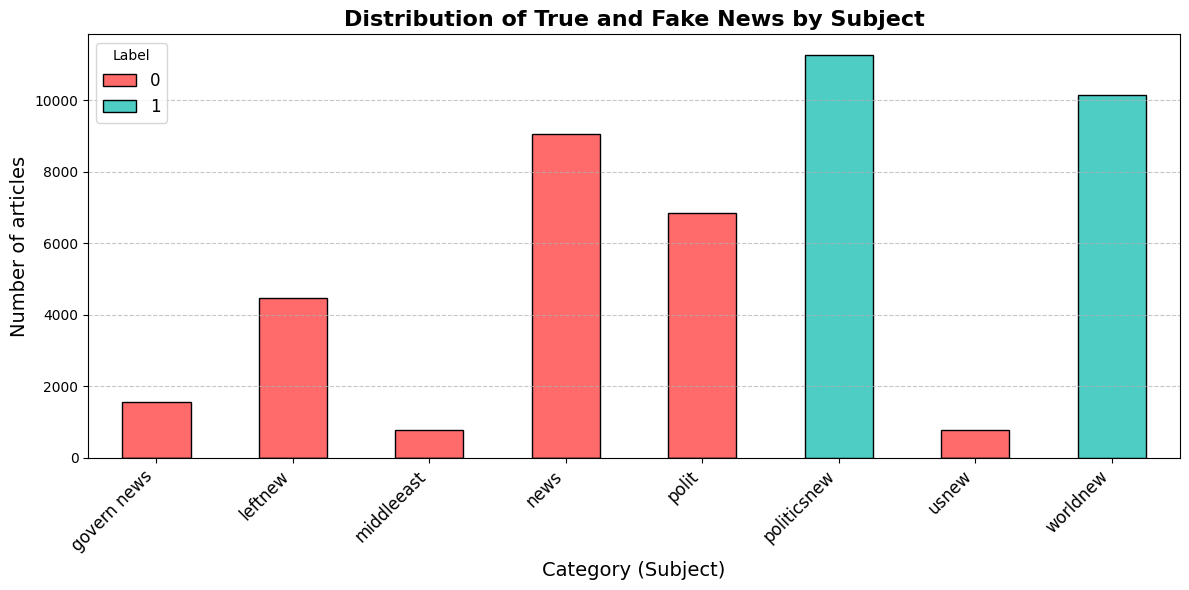

In [17]:
analyse_sujet = pd.crosstab(df1['subject'], df1['label'])

print("Exact distribution table:")
display(analyse_sujet)

plt.figure(figsize=(12, 6))

analyse_sujet.plot(kind='bar', stacked=True, color=['#ff6b6b', '#4ecdc4'], figsize=(12,6), edgecolor='black')

plt.title('Distribution of True and Fake News by Subject', fontsize=16, fontweight='bold')
plt.xlabel('Category (Subject)', fontsize=14)
plt.ylabel("Number of articles", fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.legend(title='Label', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

,Type,Method,NbFeatures,Accuracy,Precision,Recall,F1-Score,CVMean
2,With cheating,ANOVA,5000,99.93%,99.93%,99.93%,99.93%,99.92%
0,With cheating,Without Selection,7043,99.92%,99.92%,99.92%,99.92%,99.91%
1,With cheating,Fisher (chi2),5000,99.92%,99.92%,99.92%,99.92%,99.90%
3,With cheating,LDA,1,99.48%,99.49%,99.48%,99.48%,99.45%
6,Without cheating,LDA,1,97.61%,97.65%,97.61%,97.61%,97.55%
5,Without cheating,ANOVA,6400,94.95%,94.98%,94.95%,94.95%,94.80%
4,Without cheating,Fisher (chi2),6400,93.53%,93.55%,93.53%,93.53%,93.40%


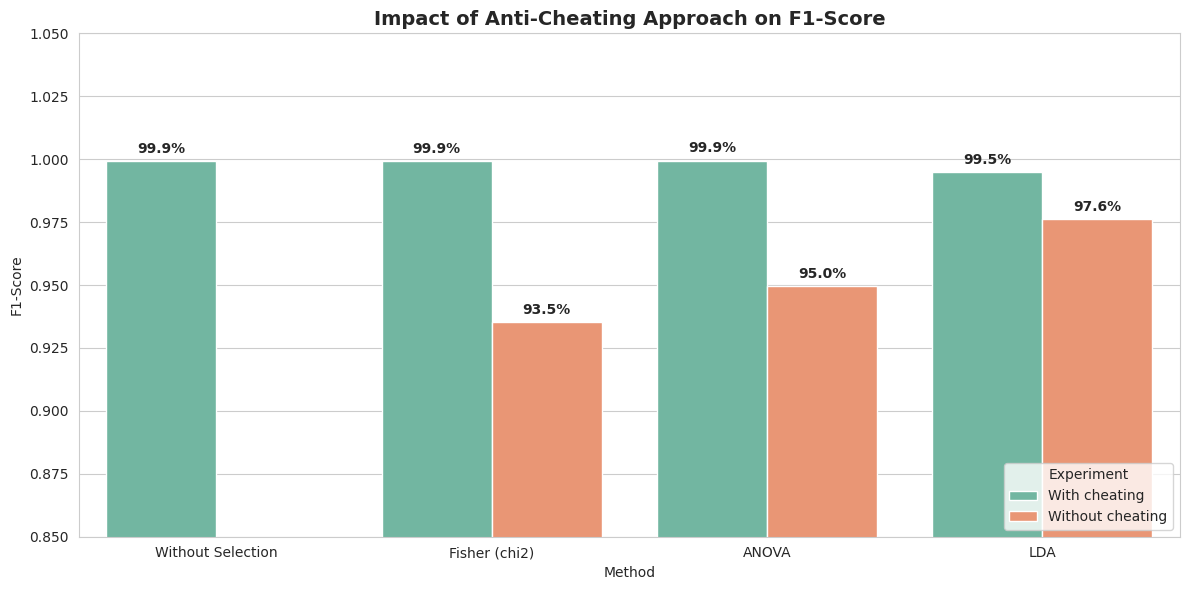

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = [

    {"Type": "With cheating", "Method": "Without Selection", "NbFeatures": 7043, "Accuracy": 0.9992, "Precision": 0.9992, "Recall": 0.9992, "F1-Score": 0.9992, "CVMean": 0.9991},
    {"Type": "With cheating", "Method": "Fisher (chi2)", "NbFeatures": 5000, "Accuracy": 0.9992, "Precision": 0.9992, "Recall": 0.9992, "F1-Score": 0.9992, "CVMean": 0.9990},
    {"Type": "With cheating", "Method": "ANOVA", "NbFeatures": 5000, "Accuracy": 0.9993, "Precision": 0.9993, "Recall": 0.9993, "F1-Score": 0.9993, "CVMean": 0.9992},
    {"Type": "With cheating", "Method": "LDA", "NbFeatures": 1, "Accuracy": 0.9948, "Precision": 0.9949, "Recall": 0.9948, "F1-Score": 0.9948, "CVMean": 0.9945},
    

    {"Type": "Without cheating", "Method": "Fisher (chi2)", "NbFeatures": 6400, "Accuracy": 0.9353, "Precision": 0.9355, "Recall": 0.9353, "F1-Score": 0.9353, "CVMean": 0.9340},
    {"Type": "Without cheating", "Method": "ANOVA", "NbFeatures": 6400, "Accuracy": 0.9495, "Precision": 0.9498, "Recall": 0.9495, "F1-Score": 0.9495, "CVMean": 0.9480},
    {"Type": "Without cheating", "Method": "LDA", "NbFeatures": 1, "Accuracy": 0.9761, "Precision": 0.9765, "Recall": 0.9761, "F1-Score": 0.9761, "CVMean": 0.9755},
]

df_results = pd.DataFrame(data)

df_sorted = df_results.sort_values(['Type', 'F1-Score'], ascending=[True, False])
display(df_sorted.style.background_gradient(subset=['Accuracy', 'F1-Score'], cmap='YlGnBu')
        .format({'Accuracy': '{:.2%}', 'Precision': '{:.2%}', 'Recall': '{:.2%}', 'F1-Score': '{:.2%}', 'CVMean': '{:.2%}'}))

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

ax = sns.barplot(data=df_results, x='Method', y='F1-Score', hue='Type', palette='Set2')

plt.title('Impact of Anti-Cheating Approach on F1-Score', fontsize=14, fontweight='bold')
plt.ylim(0.85, 1.05) 
plt.ylabel('F1-Score')
plt.legend(title='Experiment', loc='lower right')

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(format(p.get_height(), '.1%'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha='center', va='center', 
                   xytext=(0, 9), 
                   textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()

